In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_ABS_PATH = 'D:/Documents-D/UTEC/Data-visualization/ds004902' # path absoluto de los datos. Tmb podría ser relativo.

# Explorar datos generales de los participantes

In [3]:
participants_data_path = f'{DATA_ABS_PATH}/participants.tsv'
df = pd.read_csv(participants_data_path, sep='\t')
df.head()

,participant_id,Gender,Age,SessionOrder,EEG_SamplingTime_Open_NS,EEG_SamplingTime_Closed_NS,EEG_SamplingTime_Open_SD,EEG_SamplingTime_Closed_SD,PVT_SamplingTime_NS,PVT_SamplingTime_SD,...,EQ,Buss_Perry,PSQI_GlobalScore,PSQI_item1,PSQI_item2,PSQI_item3,PSQI_item4,PSQI_item5,PSQI_item6,PSQI_item7
0,sub-01,M,22,NS->SD,8:57:52,9:04:40,8:18:28,8:25:34,9:27:23,9:23:08,...,NaN,NaN,4.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0
1,sub-02,M,21,NS->SD,9:47:46,9:53:24,8:54:10,8:59:50,10:16:59,10:00:47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sub-03,F,19,NS->SD,8:49:46,8:55:38,9:58:36,10:04:08,8:45:04,9:34:13,...,NaN,NaN,7.0,2.0,1.0,0.0,1.0,2.0,0.0,1.0
3,sub-04,M,22,NS->SD,9:53:56,9:59:34,9:07:02,9:12:26,10:05:35,10:06:28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-05,F,18,NS->SD,20:37:12,20:47:34,9:09:00,9:14:34,21:01:57,10:07:33,...,NaN,NaN,3.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   participant_id              71 non-null     str    
 1   Gender                      71 non-null     str    
 2   Age                         71 non-null     int64  
 3   SessionOrder                71 non-null     str    
 4   EEG_SamplingTime_Open_NS    71 non-null     str    
 5   EEG_SamplingTime_Closed_NS  38 non-null     str    
 6   EEG_SamplingTime_Open_SD    71 non-null     str    
 7   EEG_SamplingTime_Closed_SD  38 non-null     str    
 8   PVT_SamplingTime_NS         37 non-null     str    
 9   PVT_SamplingTime_SD         36 non-null     str    
 10  PVT_item1_NS                31 non-null     float64
 11  PVT_item2_NS                31 non-null     float64
 12  PVT_item3_NS                31 non-null     float64
 13  PVT_item1_SD                37 non-null     floa

In [5]:
mv = pd.DataFrame(df.isna().sum())
mv = mv.reset_index().rename(columns={0:'value'})
mv.head(2)

,index,value
0,participant_id,0
1,Gender,0


In [7]:
# Completar el data dictionary
data_dict = pd.read_csv('data_dictionary.csv')
# data_dict = data_dict.merge(right=mv, how='inner', right_on='index', left_on='field_name').drop(columns=['known_missing_value_codes', 'index']).rename(columns={'value':'missing_values'})
data_dict.to_csv('data_dictionary.csv', index=False)

Filas sin nulos: (array([], dtype=int64),)


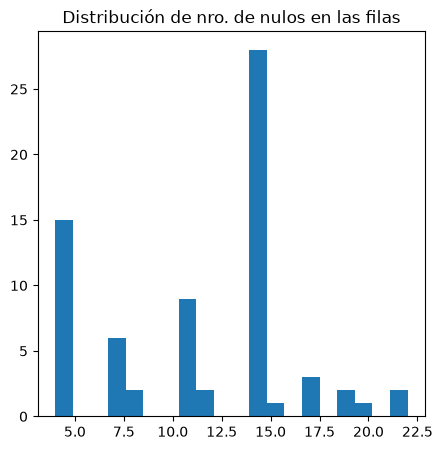

In [8]:
# Hay alguna fila sin nulos?
print(f'Filas sin nulos: {np.where(df.isna().sum(axis=1)==0)}')

plt.figure(figsize=(5,5))
plt.hist(df.drop(columns=['participant_id']).isna().sum(axis=1), bins=20)
plt.title('Distribución de nro. de nulos en las filas')
plt.show()

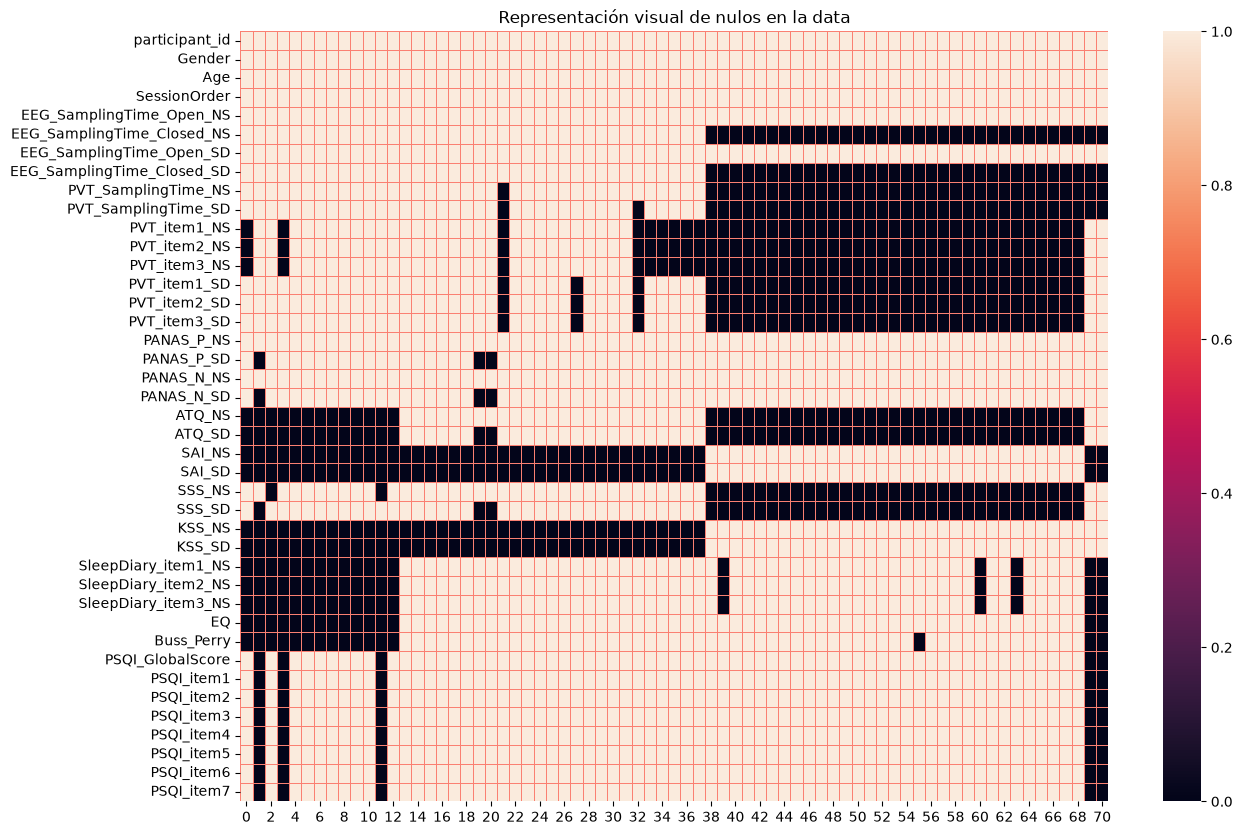

In [9]:
# Patrones en ausencia de datos O.o
plt.figure(figsize=(14, 10))
sns.heatmap(df.notna().transpose(), linewidths=0.6, linecolor='salmon')
plt.title('Representación visual de nulos en la data')
plt.show() # Los azules son donde hay nulos.

# Exploración de metadata de tasks

Cada "task" es una prueba donde se le hizo EEG a un participante. Cada task tiene metadatos en JSON.

In [10]:
from pathlib import Path
import json
import pandas as pd

data_path = Path(DATA_ABS_PATH)

records = []

for json_path in data_path.rglob("*_eeg.json"):
    with json_path.open("r", encoding="utf-8") as file:
        metadata = json.load(file)

    json_path_parts = str(json_path).split('\\')
    metadata["participant_id"] = json_path_parts[5]
    metadata["session"] = json_path_parts[6]

    records.append(metadata)

eeg_metadata_df = pd.DataFrame(records)

# Preprocesamiento. Eliminar columnas que no serán relevantes.
eeg_metadata_df = eeg_metadata_df.drop(columns=['SoftwareFilters', 'InstitutionAddress'])

eeg_metadata_df.head()

,PowerLineFrequency,EEGReference,InstitutionalDepartmentName,InstitutionName,EEGPlacementScheme,CapManufacturer,TaskName,EEGChannelCount,RecordingType,RecordingDuration,SamplingFrequency,EOGChannelCount,ECGChannelCount,EMGChannelCount,participant_id,session
0,50,FCz,Faculty of Psychology,Southwest University,10-20,Brain Products GmbH,eyesopen,61,continuous,300.0,500,0,0,0,sub-71,ses-2
1,50,FCz,Faculty of Psychology,Southwest University,10-20,Brain Products GmbH,eyesopen,61,continuous,300.0,500,0,0,0,sub-71,ses-1
2,50,FCz,Faculty of Psychology,Southwest University,10-20,Brain Products GmbH,eyesopen,61,continuous,300.0,500,0,0,0,sub-70,ses-2
3,50,FCz,Faculty of Psychology,Southwest University,10-20,Brain Products GmbH,eyesopen,61,continuous,300.0,500,0,0,0,sub-70,ses-1
4,50,FCz,Faculty of Psychology,Southwest University,10-20,Brain Products GmbH,eyesopen,61,continuous,300.0,500,0,0,0,sub-69,ses-2


In [19]:
eeg_metadata_df.columns

Index(['PowerLineFrequency', 'EEGReference', 'InstitutionalDepartmentName',
       'InstitutionName', 'EEGPlacementScheme', 'CapManufacturer', 'TaskName',
       'EEGChannelCount', 'RecordingType', 'RecordingDuration',
       'SamplingFrequency', 'EOGChannelCount', 'ECGChannelCount',
       'EMGChannelCount', 'participant_id', 'session'],
      dtype='str')

In [11]:
eeg_metadata_df.info() # No hay nulos :3

<class 'pandas.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   PowerLineFrequency           218 non-null    int64  
 1   EEGReference                 218 non-null    str    
 2   InstitutionalDepartmentName  218 non-null    str    
 3   InstitutionName              218 non-null    str    
 4   EEGPlacementScheme           218 non-null    str    
 5   CapManufacturer              218 non-null    str    
 6   TaskName                     218 non-null    str    
 7   EEGChannelCount              218 non-null    int64  
 8   RecordingType                218 non-null    str    
 9   RecordingDuration            218 non-null    float64
 10  SamplingFrequency            218 non-null    int64  
 11  EOGChannelCount              218 non-null    int64  
 12  ECGChannelCount              218 non-null    int64  
 13  EMGChannelCount              21

In [12]:
# Ver cuántos valores distintos existen en cada columna. Sospechamos que en algunos debería repetirse el mismo (ej: EEGReference = 50)
cols_with_different_values = []
for col in eeg_metadata_df.columns:
    unicos = eeg_metadata_df[col].unique()
    n_values = len(eeg_metadata_df[col].unique())
    print(f'Valores distintos en {col}: {n_values}')
    if n_values > 1:
        cols_with_different_values.append(col)
print("="*40, '\n')
# De los que tienen más de un valor, ver cuáles son
for col in cols_with_different_values:
    if col == 'session' or col == 'participant_id':
        continue
    unicos = eeg_metadata_df[col].value_counts()
    print(f'Valores de {col}: {unicos}\n')

Valores distintos en PowerLineFrequency: 1
Valores distintos en EEGReference: 1
Valores distintos en InstitutionalDepartmentName: 1
Valores distintos en InstitutionName: 1
Valores distintos en EEGPlacementScheme: 1
Valores distintos en CapManufacturer: 1
Valores distintos en TaskName: 2
Valores distintos en EEGChannelCount: 1
Valores distintos en RecordingType: 1
Valores distintos en RecordingDuration: 10
Valores distintos en SamplingFrequency: 2
Valores distintos en EOGChannelCount: 1
Valores distintos en ECGChannelCount: 1
Valores distintos en EMGChannelCount: 1
Valores distintos en participant_id: 71
Valores distintos en session: 2

Valores de TaskName: TaskName
eyesopen      142
eyesclosed     76
Name: count, dtype: int64

Valores de RecordingDuration: RecordingDuration
300.00    209
237.84      1
283.58      1
248.98      1
288.22      1
264.82      1
251.44      1
364.78      1
290.84      1
295.84      1
Name: count, dtype: int64

Valores de SamplingFrequency: SamplingFrequency


Observamos que si bien `RecordingDuration` debió de ser 5 minutos siempre (300 segundos), hay algunos tasks que no cumplen con esto. 

Asimismo, hay algunos `SamplingFrequency` que no son de 500Hz, sino 5000Hz, quizás se debe a un error de digitación.

Adicionalmente, si todos los participantes hubieran cumplido sus 4 tasks (SD-eyesclosed, SD-eyesopen, NS-eyesclosed, NS-eyesopen), deberíamos 4 * 71 = 284 filas, pero sólo tenemos 218 (diferencia de 66 tasks).

# Exploración de posiciones de los electrodos

In [13]:
data_path = Path(DATA_ABS_PATH)

electrode_records = []

for tsv_path in data_path.rglob("*_electrodes.tsv"):
    one_df = pd.read_csv(tsv_path, sep='\t')

    tsv_path_parts = str(tsv_path).split('\\')
    one_df["participant_id"] = tsv_path_parts[5]
    one_df["session"] = tsv_path_parts[6]
    electrode_records.append(one_df)

electrode_df = pd.concat(electrode_records)
electrode_df.head()

,name,x,y,z,manufacturer,participant_id,session
0,Fp1,80.7840,26.1330,-4.0011,Brain Products GmbH,sub-71,ses-2
1,AF3,76.1528,31.4828,20.8468,Brain Products GmbH,sub-71,ses-2
2,AF7,68.6911,49.7094,-5.9589,Brain Products GmbH,sub-71,ses-2
3,Fz,60.7385,0.0000,59.4629,Brain Products GmbH,sub-71,ses-2
4,F1,59.9127,26.0421,54.3808,Brain Products GmbH,sub-71,ses-2


In [14]:
electrode_df.info()

<class 'pandas.DataFrame'>
Index: 8662 entries, 0 to 60
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            8662 non-null   str    
 1   x               8662 non-null   float64
 2   y               8662 non-null   float64
 3   z               8662 non-null   float64
 4   manufacturer    8662 non-null   str    
 5   participant_id  8662 non-null   str    
 6   session         8662 non-null   str    
dtypes: float64(3), str(4)
memory usage: 541.4 KB


In [15]:
assert len(electrode_df.name.unique()) == 61, "No hay 61 electrodos."

In [ ]:
electrode_df.manufacturer.unique()

<StringArray>
['Brain Products GmbH']
Length: 1, dtype: str

# Visualizaciíon de un EEG

In [17]:
# path de un eeg de una sesión de un participante con los ojos cerrados
sample_path = f'{DATA_ABS_PATH}/sub-01/ses-1/eeg/sub-01_ses-1_task-eyesclosed_eeg.set'

raw = mne.io.read_raw_eeglab(sample_path, preload=True)
raw

Reading D:\Documents-D\UTEC\Data-visualization\ds004902\sub-01\ses-1\eeg\sub-01_ses-1_task-eyesclosed_eeg.fdt
Reading 0 ... 149999  =      0.000 ...   299.998 secs...


<RawEEGLAB | sub-01_ses-1_task-eyesclosed_eeg.fdt, 61 x 150000 (300.0 s), ~69.9 MiB, data loaded>

Using matplotlib as 2D backend.


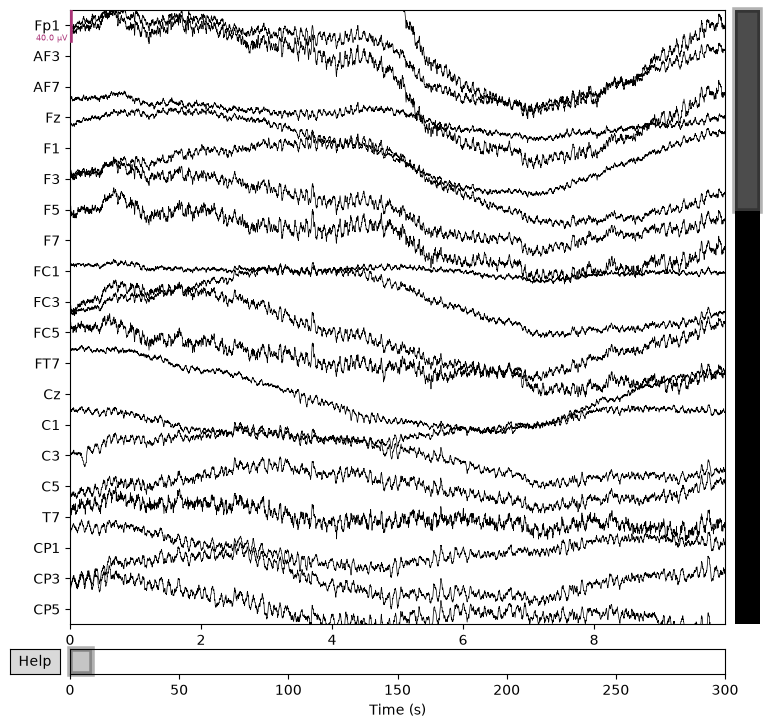

Channels marked as bad:
none


In [18]:
# Vista interactiva. Debería salir como popup! Puedes moverlo con las flechas del teclado.
%matplotlib qt
raw.plot()